# Final Project

#### Title: Machine Learning for Obesity Level Prediction and Lifesytle Pattern Discovery
#### Class: AAI 501-02 - Introduction to Artificial Intelligence
#### Team 4: Dina Othman, Erika Gallegos, Hassaan Abbasi

In [1]:
!pip install xgboost

In [2]:
## libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.sparse import hstack
from xgboost import plot_tree

import os
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid", context="notebook")

## Data

In [3]:
# Import data from Github

url = 'https://raw.githubusercontent.com/hassaanabbasi98/ProjectAAI-501-ObseityLevel-/main/ObesityDataSet_raw_and_data_sinthetic.csv'

df = pd.read_csv(url)
df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Data Cleaning

In [4]:
#  basic cleaning

# 1) Drop exact duplicate rows
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df_clean.shape)

# 2) No missing values in this dataset,
missing_counts = df_clean.isna().sum()
print("Missing values per column after cleaning:")
print(missing_counts)

# 3) Verify dtypes
print("\nData types:")
print(df_clean.dtypes)


Shape after dropping duplicates: (2087, 17)
Missing values per column after cleaning:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Data types:
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                    

## EDA

Distributions, correlations, key lifestyle variables.
Keeping the EDA on unencoded data so plots are interpretable.

In [5]:
#  column groups

target_col = "NObeyesdad"

categorical_cols = ["Gender","family_history_with_overweight","FAVC","CAEC","SMOKE","SCC","CALC","MTRANS",
    target_col,  # keep target in its own group when needed
]

numeric_cols = ["Age","Height","Weight","FCVC", "NCP","CH2O","FAF", "TUE",]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorical columns: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


Summary of Statisitcs After cleaning and EDA-Distruibution

In [6]:
print("Numeric summary:")
display(df_clean[numeric_cols].describe())

print("\nCategorical summary (value counts):")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts())

Numeric summary:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Categorical summary (value counts):

--- Gender ---
Gender
Male      1052
Female    1035
Name: count, dtype: int64

--- family_history_with_overweight ---
family_history_with_overweight
yes    1722
no      365
Name: count, dtype: int64

--- FAVC ---
FAVC
yes    1844
no      243
Name: count, dtype: int64

--- CAEC ---
CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64

--- SMOKE ---
SMOKE
no     2043
yes      44
Name: count, dtype: int64

--- SCC ---
SCC
no     1991
yes      96
Name: count, dtype: int64

--- CALC ---
CALC
Sometimes     1380
no             636
Frequently      70
Always           1
Name: count, dtype: int64

--- MTRANS ---
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64

--- NObeyesdad ---
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Ove

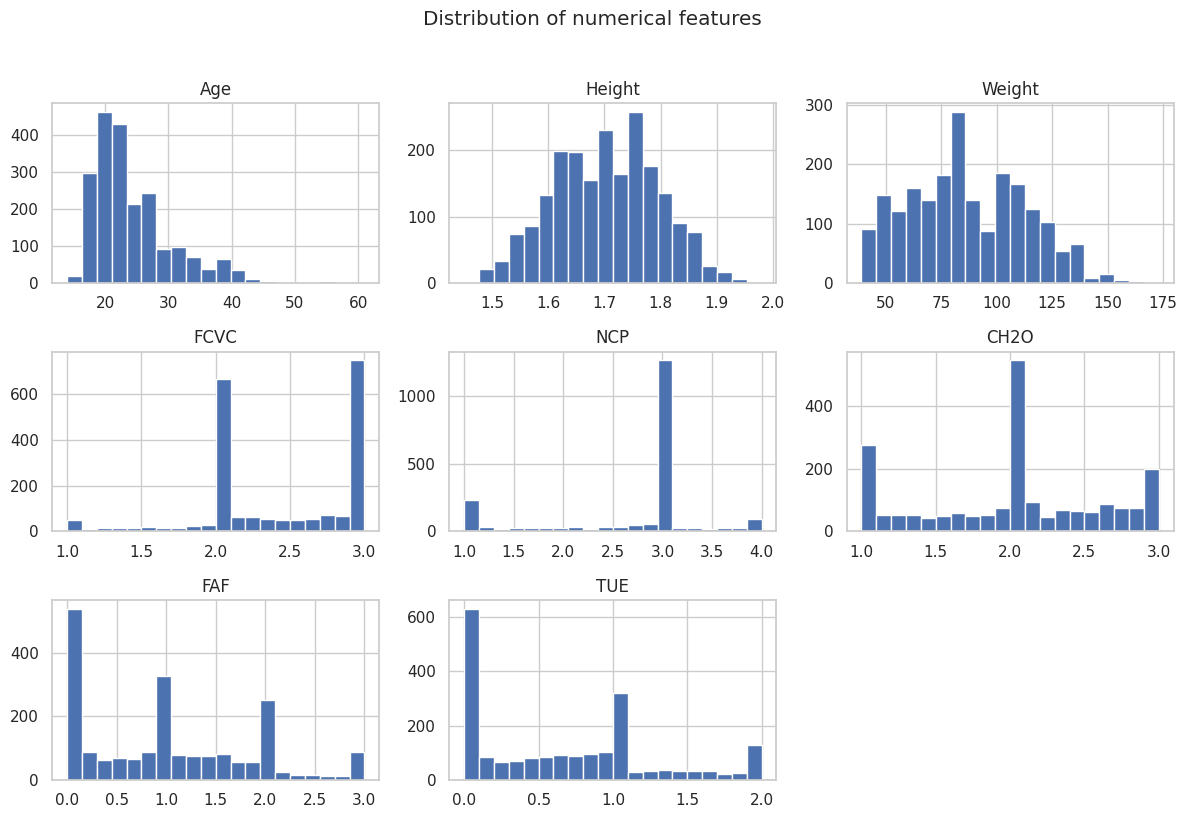

In [7]:
# histograms for numeric features
df_clean[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribution of numerical features", y=1.02)
plt.tight_layout()
plt.show()


Target Distribution

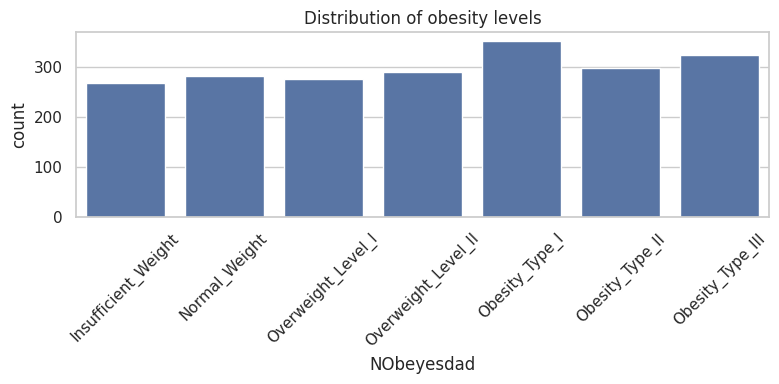

In [8]:
# target distribution

obesity_order = ["Insufficient_Weight","Normal_Weight", "Overweight_Level_I","Overweight_Level_II","Obesity_Type_I","Obesity_Type_II","Obesity_Type_III",]

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_clean,
    x=target_col,
    order=obesity_order,
)
plt.xticks(rotation=45)
plt.title("Distribution of obesity levels")
plt.tight_layout()
plt.show()


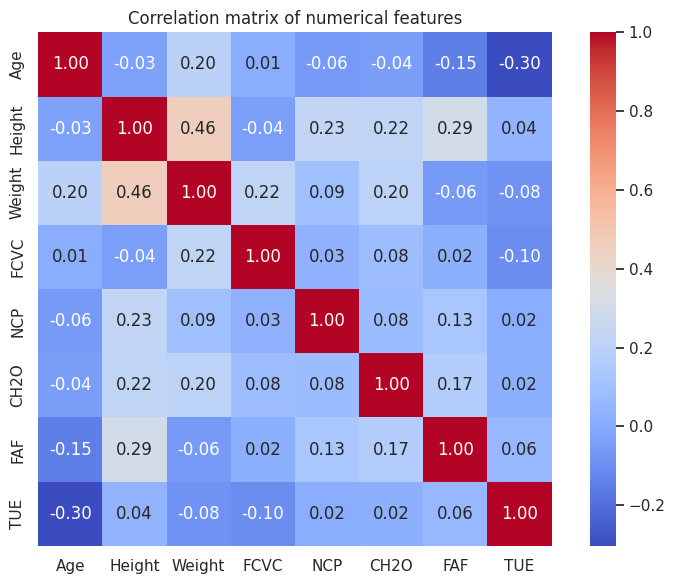

In [9]:
# correlation matrix

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix of numerical features")
plt.tight_layout()
plt.show()


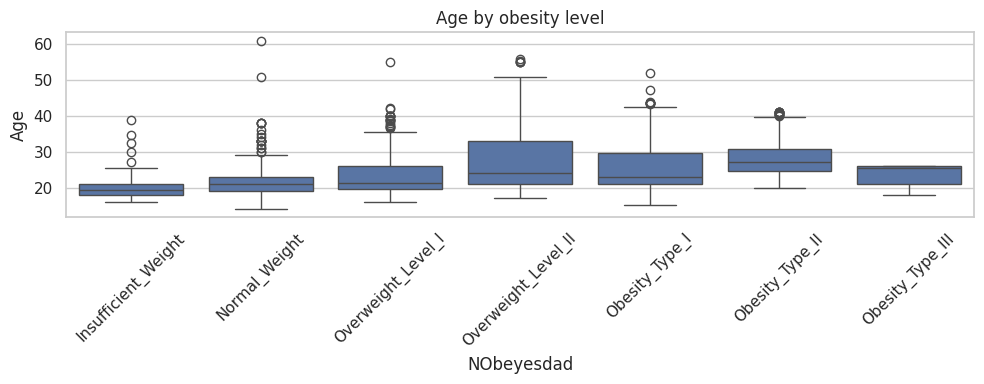

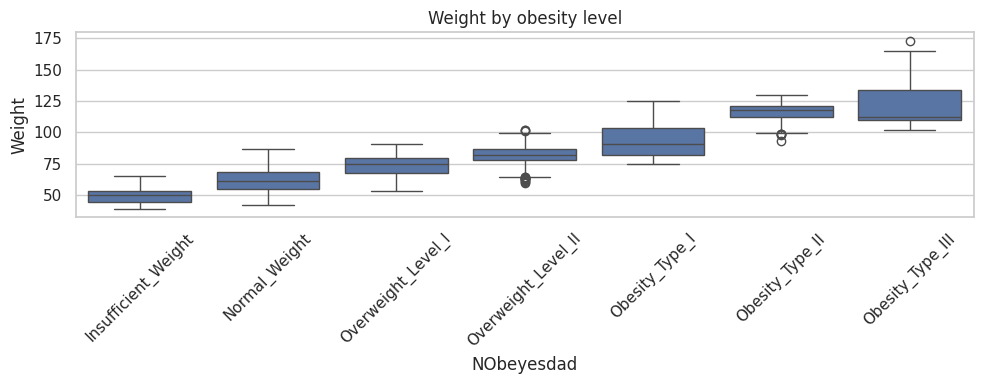

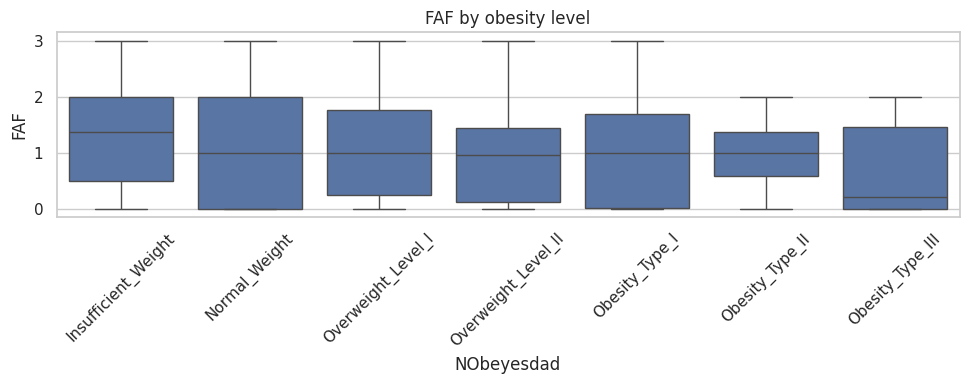

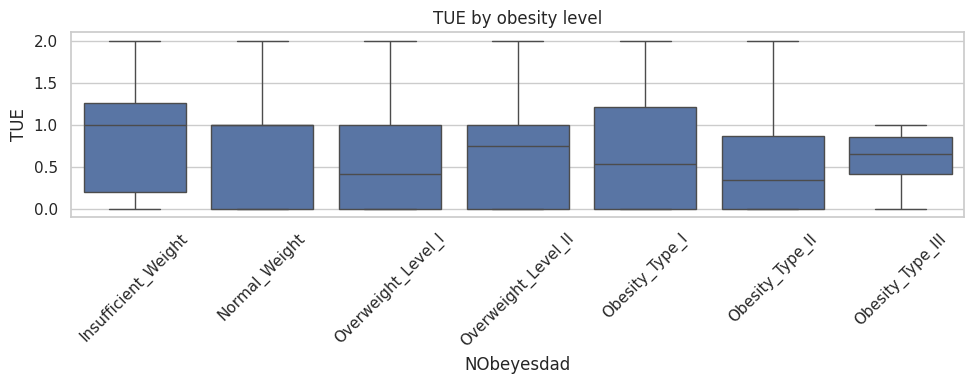

In [10]:
# numeric and obesity level difference

for col in ["Age", "Weight", "FAF", "TUE"]:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_clean,x=target_col,y=col,order=obesity_order,)
    plt.xticks(rotation=45)
    plt.title(f"{col} by obesity level")
    plt.tight_layout()
    plt.show()


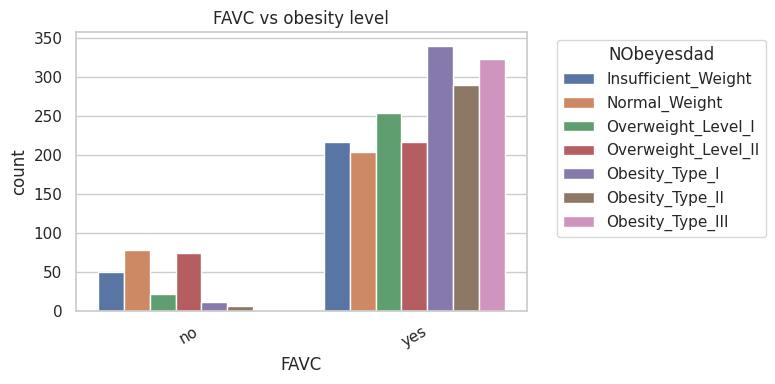

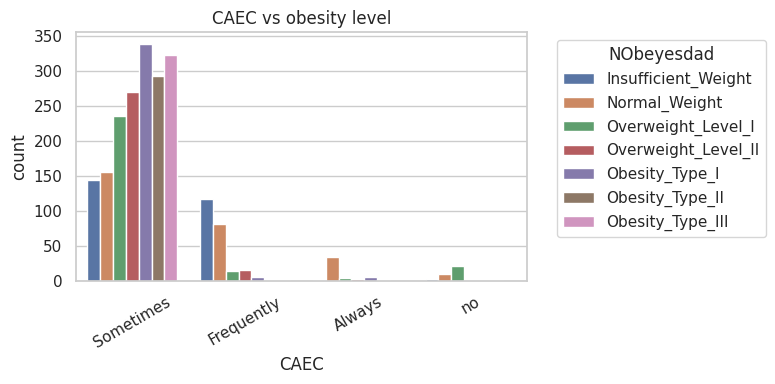

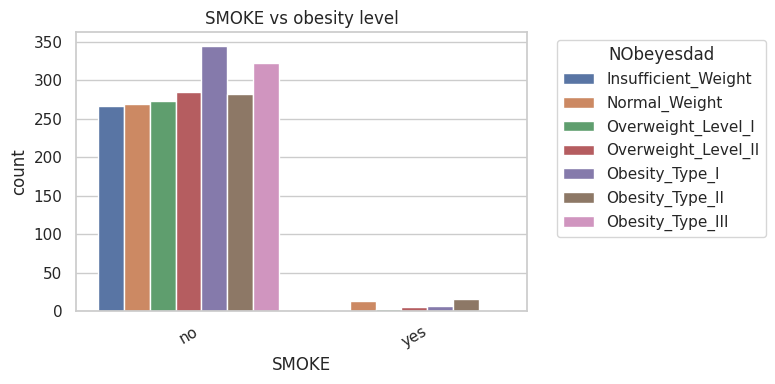

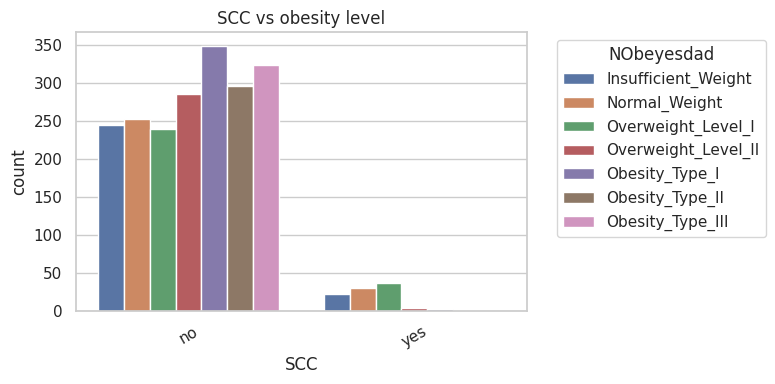

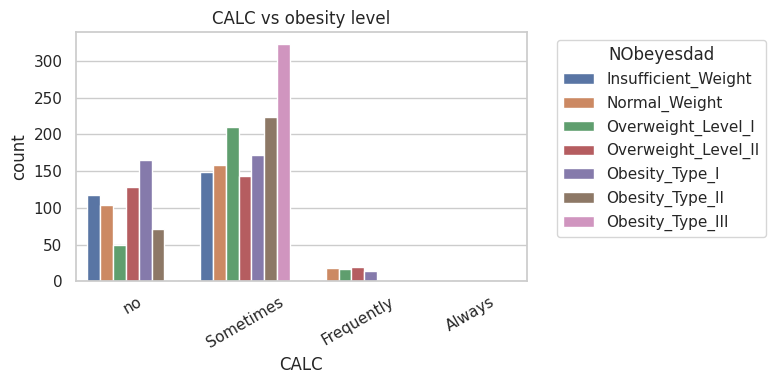

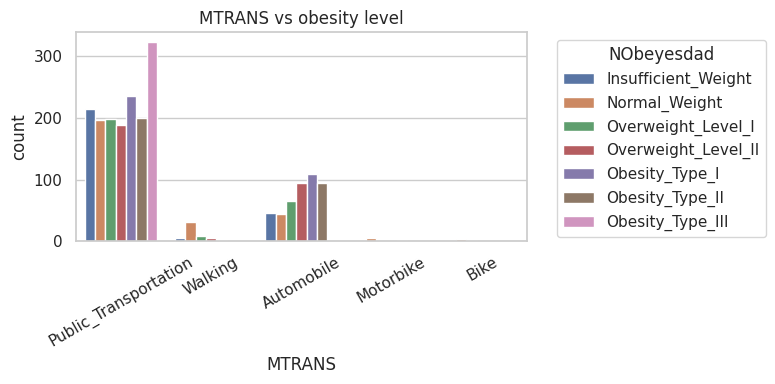

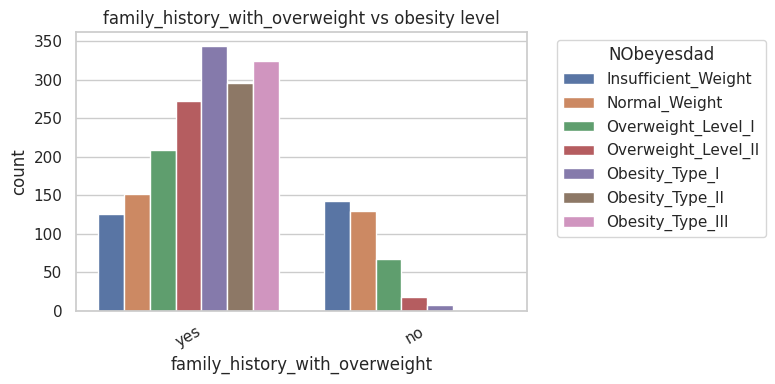

In [11]:
#  helper function for lifestyle categorical variables vs obesity

def plot_cat_vs_obesity(df, cat_col, target_col="NObeyesdad", order=None):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df,x=cat_col, hue=target_col,hue_order=obesity_order,order=order,)
    plt.xticks(rotation=30)
    plt.title(f"{cat_col} vs obesity level")
    plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()



    # lifestyle variables vs obesity level
    # Got a help from chatgpt, to help me plot it nicely with different colors

plot_cat_vs_obesity(df_clean, "FAVC", target_col)   # high-calorie food
plot_cat_vs_obesity(df_clean, "CAEC", target_col)   # eating between meals
plot_cat_vs_obesity(df_clean, "SMOKE", target_col)
plot_cat_vs_obesity(df_clean, "SCC", target_col)    # calorie monitoring
plot_cat_vs_obesity(df_clean, "CALC", target_col)   # alcohol
plot_cat_vs_obesity(df_clean, "MTRANS", target_col) # transportation mode
plot_cat_vs_obesity(df_clean, "family_history_with_overweight", target_col)

In [12]:
# encode categorical features (excluding target)

feature_cat_cols = ["Gender","family_history_with_overweight", "FAVC", "CAEC","SMOKE", "SCC","CALC", "MTRANS",]

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].copy()          # target

X_encoded = pd.get_dummies(X,columns=feature_cat_cols,
    drop_first=True,   # avoid dummy variable
)

print("Shape after encoding:", X_encoded.shape)
X_encoded.head()

Shape after encoding: (2087, 23)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,False,True,...,False,False,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,False,True,...,False,True,True,False,True,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,True,True,...,False,False,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,True,False,...,False,False,False,False,True,False,False,False,True,False


In [13]:
# scale numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# numeric columns are unchanged by encoding, so we can reuse the list
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])
X_encoded[numeric_cols].head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,-0.526613,-0.887408,-0.872985,-0.788364,0.390906,-0.007810,-1.186977,0.554211
1,-0.526613,-1.960788,-1.178508,1.082164,0.390906,1.636552,2.328908,-1.090505
2,-0.212507,1.044677,-0.376509,-0.788364,0.390906,-0.007810,1.156947,0.554211
3,0.415705,1.044677,0.005395,1.082164,0.390906,-0.007810,1.156947,-1.090505
4,-0.369560,0.830001,0.112328,-0.788364,-2.225418,-0.007810,-1.186977,-1.090505


# unsupervised learning machine

## (1) Unsupervised learning: K-means

In [14]:
#Prepare the features for K-Means
X_kmeans = X_encoded.copy()


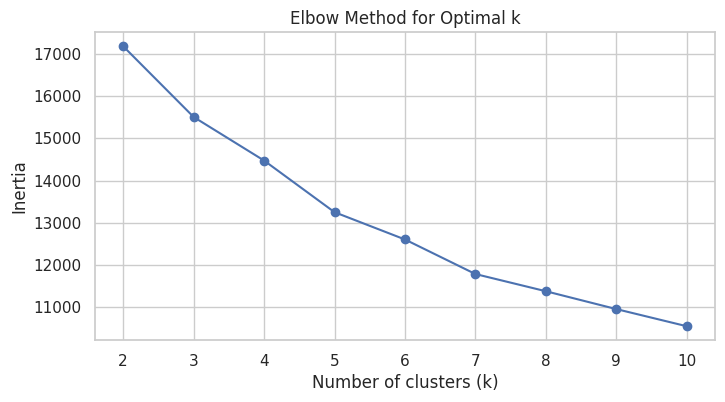

In [15]:
#Find the best k using the elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_kmeans)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o')
plt.xticks(K)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()


The inertia curve begins to flatten at k = 5, so we select k = 5 as the optimal number of clusters.

In [16]:
#Fit K-Means with k = 5
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_kmeans)

#Add cluster labels to the dataset
df_clean['Cluster'] = clusters
df_clean[['NObeyesdad', 'Cluster']].head()


,NObeyesdad,Cluster
0,Normal_Weight,1
1,Normal_Weight,1
2,Normal_Weight,1
3,Overweight_Level_I,3
4,Overweight_Level_II,0


Visualize numeric features by cluster

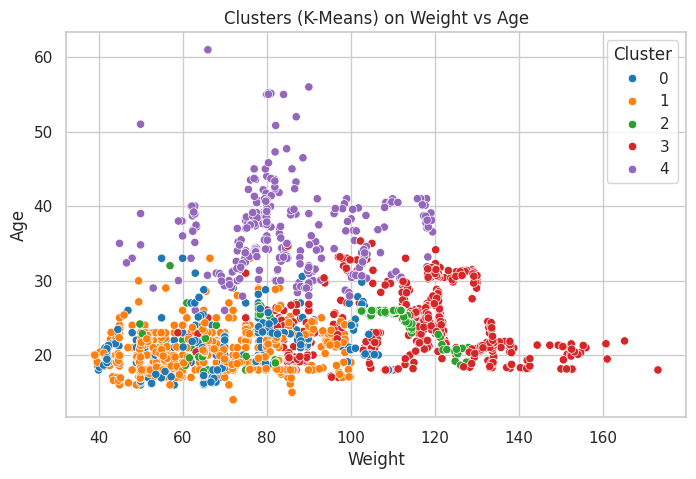

In [17]:
# Weight vs Age colored by cluster
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="Weight",
    y="Age",
    hue="Cluster",
    palette="tab10"
)
plt.title("Clusters (K-Means) on Weight vs Age")
plt.show()


Compare true obesity levels vs clusters

In [18]:
pd.crosstab(df_clean['Cluster'], df_clean['NObeyesdad'])


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,49,50,61,29,0,64,39
1,205,179,90,4,0,104,92
2,2,21,7,0,194,11,16
3,8,15,103,202,130,46,58
4,3,17,90,62,0,51,85


The K-means clusters show meaningful separation, with Cluster 1 dominated by normal/underweight individuals, Cluster 2 isolating the most severe obesity cases, Cluster 3 capturing moderate to high obesity levels, and Clusters 0 and 4 grouping overweight and mild obesity categories.

 **silhouette score**

In [19]:
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_avg = silhouette_score(X_kmeans, clusters)
print("Silhouette Score:", round(silhouette_avg, 4))



Silhouette Score: 0.1242


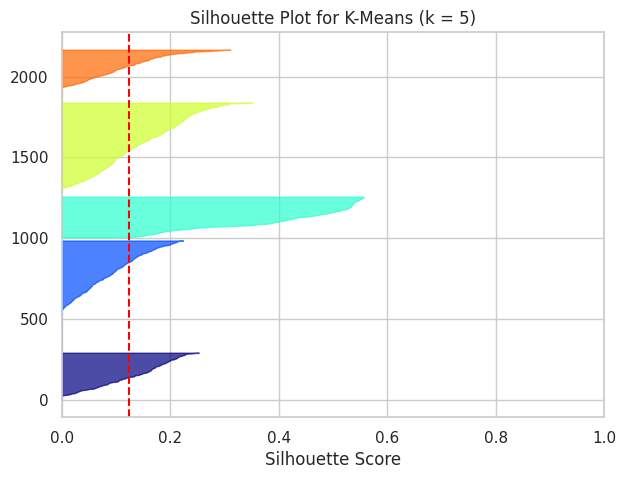

In [20]:
silhouette_vals = silhouette_samples(X_kmeans, clusters)
k = 5

fig, ax = plt.subplots(figsize=(7, 5))
y_lower = 0

for i in range(k):
    coeffs = silhouette_vals[clusters == i]
    coeffs.sort()

    color = plt.cm.jet(i / k)
    y_upper = y_lower + len(coeffs)

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        coeffs,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )

    y_lower = y_upper + 20

# plot average silhouette score line
ax.axvline(silhouette_avg, color="red", linestyle="--")

ax.set_xlim([0, 1])
ax.set_xlabel("Silhouette Score")
ax.set_title("Silhouette Plot for K-Means (k = %d)" % k)
plt.show()



The average silhouette score of 0.12 indicates weak but meaningful separation between clusters. The silhouette plot also shows that most points have positive values, suggesting that the clusters are valid, although some overlap exists, which is expected for lifestyle and obesity data. Overall, the clustering captures general patterns but the boundaries between groups are not strongly defined.

## (2) Unsupervised learning: Dimensionality Reduction with PCA

In [21]:
from sklearn.decomposition import PCA

# Fitting PCA
# reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_kmeans)


In [22]:
## Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", pca.explained_variance_ratio_.sum())


Explained Variance Ratio: [0.20026567 0.16326345]
Total Variance Explained: 0.36352912545284144


PC1 and PC2 together capture about 36% of the dataset’s variance, providing a useful but not fully complete 2-D representation of the data.

**PCA scatter plot**

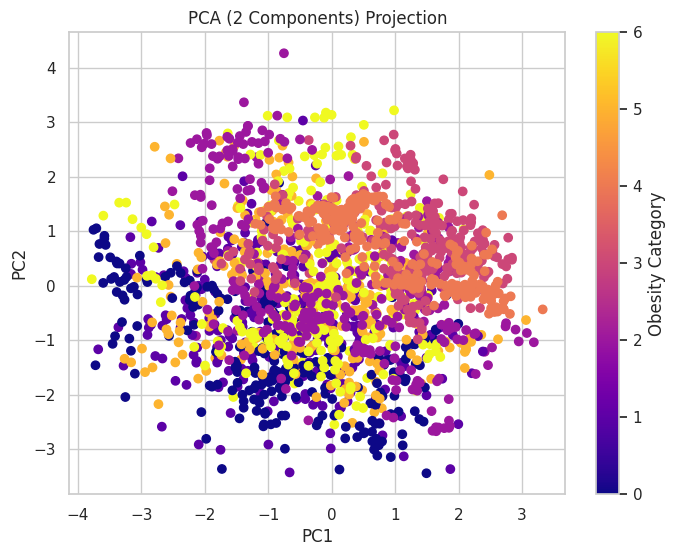

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=pd.Categorical(df_clean['NObeyesdad']).codes,
    cmap='plasma'
)
plt.colorbar(label='Obesity Category')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 Components) Projection")
plt.show()


The PCA projection shows substantial overlap between obesity categories, which is expected since lifestyle features and weight patterns do not separate cleanly in a linear 2-D space. PCA was still able to capture general trends, but not strong visual boundaries between classes.

**Scree Plot**

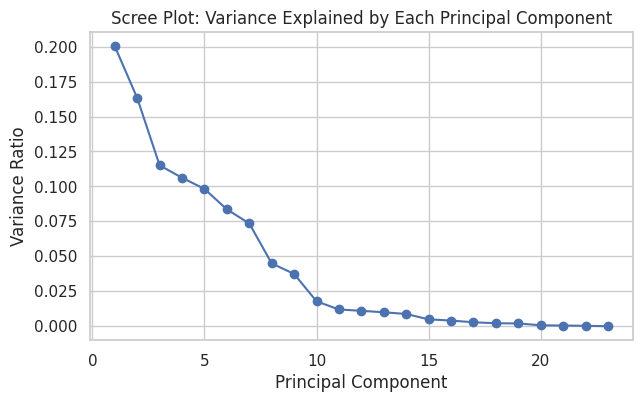

In [24]:
# Fit PCA to keep ALL components
pca_full = PCA()
pca_full.fit(X_kmeans)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_,
         marker='o')
plt.title("Scree Plot: Variance Explained by Each Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.grid(True)
plt.show()


The scree plot shows that the first few principal components capture the largest amount of variance, with PC1 and PC2 contributing the most (20% and 16%). After the first 3 to 5 components, the explained variance drops sharply, and the later components contribute minimal additional information. This confirms that using the first two components provides a reasonable low-dimensional representation, even though a significant portion of the variance remains distributed across higher components.

## Supervised Machine Learning

Predicting obesity level (NObeyesdad).

### Logistic Regression



#### Preprocessing

In [25]:
## data preparation per logistic regression formatting

# split features (x) and target (y)
X = df_clean.drop('NObeyesdad', axis = 1)
y = df_clean['NObeyesdad']

# get column types
categorical_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

# split 80% (train) / 20% (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33, stratify = y)

# one-hot encode categoricals
ohe_lr = OneHotEncoder(drop = 'first', handle_unknown = 'ignore', sparse_output = False)

# scale numerics
scaler_lr = StandardScaler()

# fit on training data
X_train_cat = ohe_lr.fit_transform(X_train[categorical_cols])
X_test_cat = ohe_lr.transform(X_test[categorical_cols])

X_train_num = scaler_lr.fit_transform(X_train[numeric_cols])
X_test_num = scaler_lr.transform(X_test[numeric_cols])

# combine numeric + categorical
X_train_lr = np.hstack([X_train_num, X_train_cat])
X_test_lr = np.hstack([X_test_num, X_test_cat])

# build feature names
encoded_cat_names = ohe_lr.get_feature_names_out(categorical_cols)
lr_feature_names = numeric_cols + list(encoded_cat_names)

#### Model

In [26]:
## train model
lr_model = LogisticRegression()

lr_model.fit(X_train_lr, y_train)

LogisticRegression()

In [27]:
## evaluate model performance on test data
y_pred_lr = lr_model.predict(X_test_lr)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

class_names = sorted(y.unique())

print('Logistic Regression Performance:')
print(f'Accuracy = {accuracy_lr:.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names = class_names, digits=4))

Logistic Regression Performance:
Accuracy = 0.8971
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight     0.8689    1.0000    0.9298        53
      Normal_Weight     0.9333    0.7368    0.8235        57
     Obesity_Type_I     0.9841    0.8857    0.9323        70
    Obesity_Type_II     0.9524    1.0000    0.9756        60
   Obesity_Type_III     0.9848    1.0000    0.9924        65
 Overweight_Level_I     0.7586    0.8000    0.7788        55
Overweight_Level_II     0.7903    0.8448    0.8167        58

           accuracy                         0.8971       418
          macro avg     0.8961    0.8953    0.8927       418
       weighted avg     0.9016    0.8971    0.8965       418



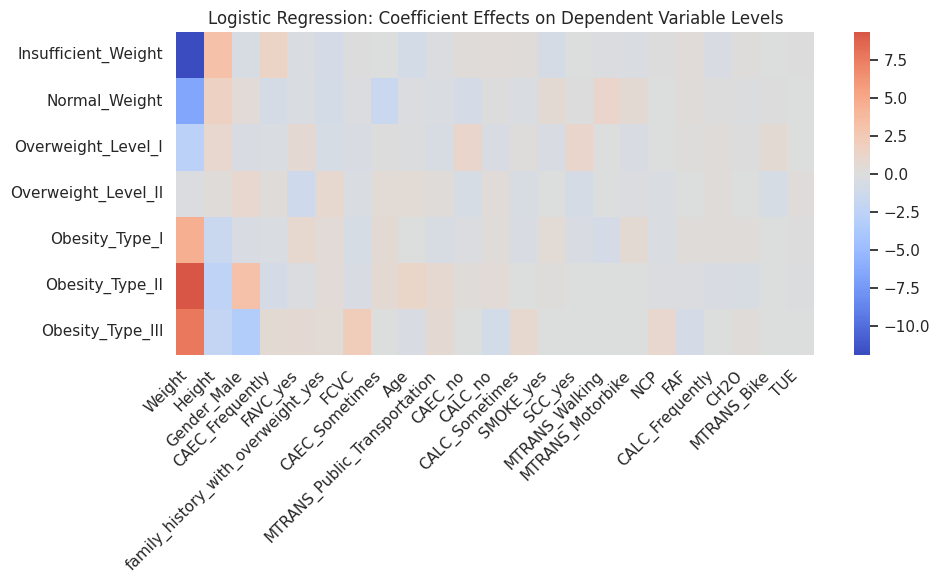

In [28]:
## visualize coefficient impact on each variable

# create dataframe
coef_lr = pd.DataFrame(lr_model.coef_,
                       columns = lr_feature_names,
                       index = lr_model.classes_)

# reorder y axis by obesity level
coef_lr = coef_lr.reindex(obesity_order)

# sort columns by total absolute coefficient magnitude
col_order = coef_lr.abs().sum(axis = 0).sort_values(ascending = False).index

# apply column sorting
coef_lr_sorted = coef_lr[col_order]

# create plot
plt.figure(figsize = (10, 6))
sns.heatmap(coef_lr_sorted, annot = False, cmap = 'coolwarm', center = 0)
plt.title('Logistic Regression: Coefficient Effects on Dependent Variable Levels')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

### Random Forest

#### Preprocessing

RF does not require scaling (unlike logistic regression)

In [29]:
## data preparation per random forest formatting

# split features (x) and target (y)
X = df_clean.drop('NObeyesdad', axis = 1)
y = df_clean['NObeyesdad']

# get column types
categorical_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

# split 80% (train) / 20% (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33, stratify = y)

# one-hot encode categoricals
ohe_rf = OneHotEncoder(drop = 'first', handle_unknown = 'ignore', sparse_output = False)

X_train_cat = ohe_rf.fit_transform(X_train[categorical_cols])
X_test_cat = ohe_rf.transform(X_test[categorical_cols])

# numeric features are passed as-is (no scaling)
X_train_num = X_train[numeric_cols].to_numpy()
X_test_num = X_test[numeric_cols].to_numpy()

# combine into dense matrix
X_train_rf = np.hstack([X_train_num, X_train_cat])
X_test_rf = np.hstack([X_test_num, X_test_cat])

# build feature names for importance plotting
encoded_cat_names = ohe_rf.get_feature_names_out(categorical_cols)
rf_feature_names = numeric_cols + list(encoded_cat_names)


#### Build Base Model

In [30]:
## base model
baseline_rf = RandomForestClassifier(random_state = 33)

## train model
baseline_rf.fit(X_train_rf, y_train)

RandomForestClassifier(random_state=33)

In [31]:
## evaluate model performance
y_pred_baseline_rf = baseline_rf.predict(X_test_rf)
accuracy_basline_rf = accuracy_score(y_test, y_pred_baseline_rf)

print('Baseline Random Forest Performance:')
print(f'Accuracy = {accuracy_basline_rf:.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred_baseline_rf, target_names = class_names, digits = 4))

Baseline Random Forest Performance:
Accuracy = 0.9474
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight     0.9608    0.9245    0.9423        53
      Normal_Weight     0.8030    0.9298    0.8618        57
     Obesity_Type_I     0.9855    0.9714    0.9784        70
    Obesity_Type_II     0.9836    1.0000    0.9917        60
   Obesity_Type_III     1.0000    1.0000    1.0000        65
 Overweight_Level_I     1.0000    0.8545    0.9216        55
Overweight_Level_II     0.9153    0.9310    0.9231        58

           accuracy                         0.9474       418
          macro avg     0.9497    0.9445    0.9456       418
       weighted avg     0.9516    0.9474    0.9480       418



#### Hyperparameter Tuning

First start with a coarse randomized search

In [32]:
## tune model - randomized search (coarse search)

# search parameters
param_options = {
    'n_estimators': [200, 400, 800],
    'max_depth': [None, 10, 20, 30, 50, 80],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'class_weight': [None, 'balanced']
}

# perform random search
random_search = RandomizedSearchCV(
    baseline_rf,
    param_distributions = param_options,
    n_iter = 40,
    cv = 3,
    scoring = 'accuracy',
    random_state = 33,
    n_jobs = -1,
    verbose = 2
)

## fit the search
random_search.fit(X_train_rf, y_train)

print('Best Hyperparameters:\n', random_search.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Hyperparameters:
 {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None, 'criterion': 'entropy', 'class_weight': None, 'bootstrap': True}


In [33]:
## evaluate model performance
y_pred_random_rf = random_search.predict(X_test_rf)
accuracy_random_rf = accuracy_score(y_test, y_pred_random_rf)

print('Randomized Search Hyperparameter Tuning for Random Forest:')
print(f'Accuracy = {accuracy_random_rf:.4f}')
print('Classification Report:')
print(classification_report(y_test, y_pred_random_rf, target_names = class_names, digits = 4))



Randomized Search Hyperparameter Tuning for Random Forest:
Accuracy = 0.9522
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight     0.9623    0.9623    0.9623        53
      Normal_Weight     0.9464    0.9298    0.9381        57
     Obesity_Type_I     0.9565    0.9429    0.9496        70
    Obesity_Type_II     0.9833    0.9833    0.9833        60
   Obesity_Type_III     1.0000    1.0000    1.0000        65
 Overweight_Level_I     0.8793    0.9273    0.9027        55
Overweight_Level_II     0.9298    0.9138    0.9217        58

           accuracy                         0.9522       418
          macro avg     0.9511    0.9513    0.9511       418
       weighted avg     0.9526    0.9522    0.9523       418



Use the output from the above search to perform a fine search around the identified best region.

In [34]:
## tune model - grid search (fine search around best region)

# best parameters from random search
best_params = random_search.best_params_

# search parameters
param_options = {
    'n_estimators': [best_params['n_estimators'] - 100,
                     best_params['n_estimators'],
                     best_params['n_estimators'] + 100],
    'max_depth': [best_params['max_depth'],
                  None],
    'min_samples_split': [best_params['min_samples_split'],
                          best_params['min_samples_split'] + 2],
    'min_samples_leaf': [best_params['min_samples_leaf'],
                         best_params['min_samples_leaf'] + 1],
    'max_features': [best_params['max_features']],
    'bootstrap': [best_params['bootstrap']],
    'criterion': [best_params['criterion']],
    'class_weight': [best_params['class_weight']]
}

# perform grid search
grid_search = GridSearchCV(
    baseline_rf,
    param_grid = param_options,
    scoring = 'accuracy',
    cv = 3,
    n_jobs = -1,
    verbose = 2
)

## fit the search
grid_search.fit(X_train_rf, y_train)

print('Best Hyperparameters from Grid Search:\n', grid_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Hyperparameters from Grid Search:
 {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 20, 'n_estimators': 200}


#### Final Model Output

In [35]:
## evaluate final tuned model

# final model
final_rf = grid_search.best_estimator_

# predict
y_pred_final = final_rf.predict(X_test_rf)
accuracy_final_rf = accuracy_score(y_test, y_pred_final)

print('Final Tuned (Best) Random Forest Model Performance:')
print(f'Accuracy = {accuracy_final_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final, target_names = class_names, digits = 4))

Final Tuned (Best) Random Forest Model Performance:
Accuracy = 0.9522

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight     0.9623    0.9623    0.9623        53
      Normal_Weight     0.9464    0.9298    0.9381        57
     Obesity_Type_I     0.9565    0.9429    0.9496        70
    Obesity_Type_II     0.9833    0.9833    0.9833        60
   Obesity_Type_III     1.0000    1.0000    1.0000        65
 Overweight_Level_I     0.8793    0.9273    0.9027        55
Overweight_Level_II     0.9298    0.9138    0.9217        58

           accuracy                         0.9522       418
          macro avg     0.9511    0.9513    0.9511       418
       weighted avg     0.9526    0.9522    0.9523       418



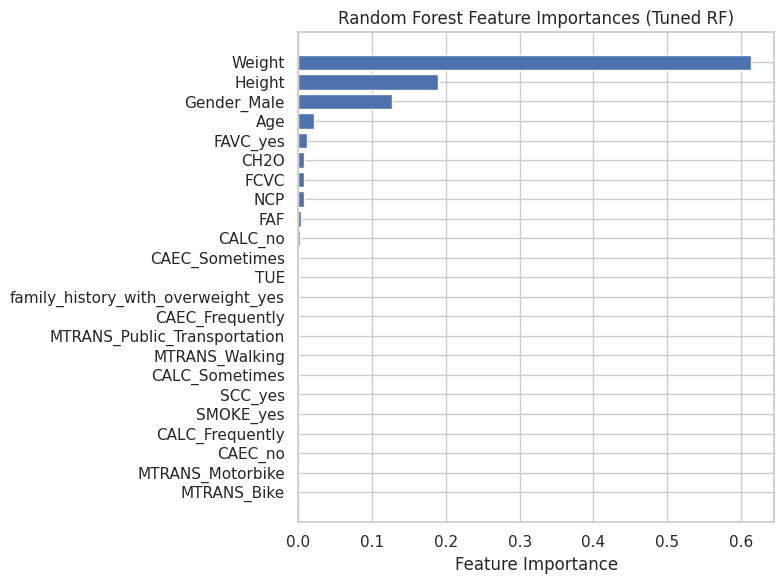

In [36]:
## create feature importance plot

# build dataframe
rf_importances = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': final_rf.feature_importances_
}).sort_values('importance', ascending = False)

# plot
plt.figure(figsize = (8, 6))
plt.barh(rf_importances['feature'], rf_importances['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances (Tuned RF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### XGBoost Model

##### Preprocessing

In [37]:
## data preparation per XGBoost formatting

# split features (x) and target (y)
X = df_clean.drop('NObeyesdad', axis = 1)
y = df_clean['NObeyesdad']

# get column types
categorical_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

# split 80% (train) / 20% (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33, stratify = y)

# one-hot encode categoricals into a sparse matrix
ohe_xgb = OneHotEncoder(
    drop = 'first',
    handle_unknown = 'ignore',
    sparse_output  =True
)

# fit OHE only on training data
X_train_cat = ohe_xgb.fit_transform(X_train[categorical_cols])
X_test_cat = ohe_xgb.transform(X_test[categorical_cols])

# numeric features: XGBoost handles scaling internally (i.e., keep raw)
X_train_num = X_train[numeric_cols].to_numpy()
X_test_num = X_test[numeric_cols].to_numpy()

# combine numeric + sparse categorical
X_train_xgb = hstack([X_train_num, X_train_cat])
X_test_xgb = hstack([X_test_num, X_test_cat])

# build feature names
encoded_cat_names = ohe_xgb.get_feature_names_out(categorical_cols)
xgb_feature_names = numeric_cols + list(encoded_cat_names)

# label encode target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

##### Model

In [38]:
## train model
best_xgb = XGBClassifier(
    objective = 'multi:softprob',
    num_class = len(le.classes_),
    eval_metric = 'mlogloss',
    tree_method = 'hist',
    random_state = 33
)

best_xgb.fit(X_train_xgb, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=7, ...)

In [39]:
## evaluate
y_pred_enc = best_xgb.predict(X_test_xgb)
y_pred = le.inverse_transform(y_pred_enc)
y_test_labels = le.inverse_transform(y_test_enc)
accuracy_xgb = accuracy_score(y_test_labels, y_pred)

print('XGB Model Performance:')
print(f'Accuracy = {accuracy_xgb:.4f}')
print('Classification Report:')
print(classification_report(y_test_labels, y_pred, digits = 4))

XGB Model Performance:
Accuracy = 0.9641
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight     0.9804    0.9434    0.9615        53
      Normal_Weight     0.8833    0.9298    0.9060        57
     Obesity_Type_I     1.0000    0.9571    0.9781        70
    Obesity_Type_II     0.9836    1.0000    0.9917        60
   Obesity_Type_III     1.0000    1.0000    1.0000        65
 Overweight_Level_I     0.9434    0.9091    0.9259        55
Overweight_Level_II     0.9508    1.0000    0.9748        58

           accuracy                         0.9641       418
          macro avg     0.9631    0.9628    0.9626       418
       weighted avg     0.9650    0.9641    0.9642       418



##### Visualize Model

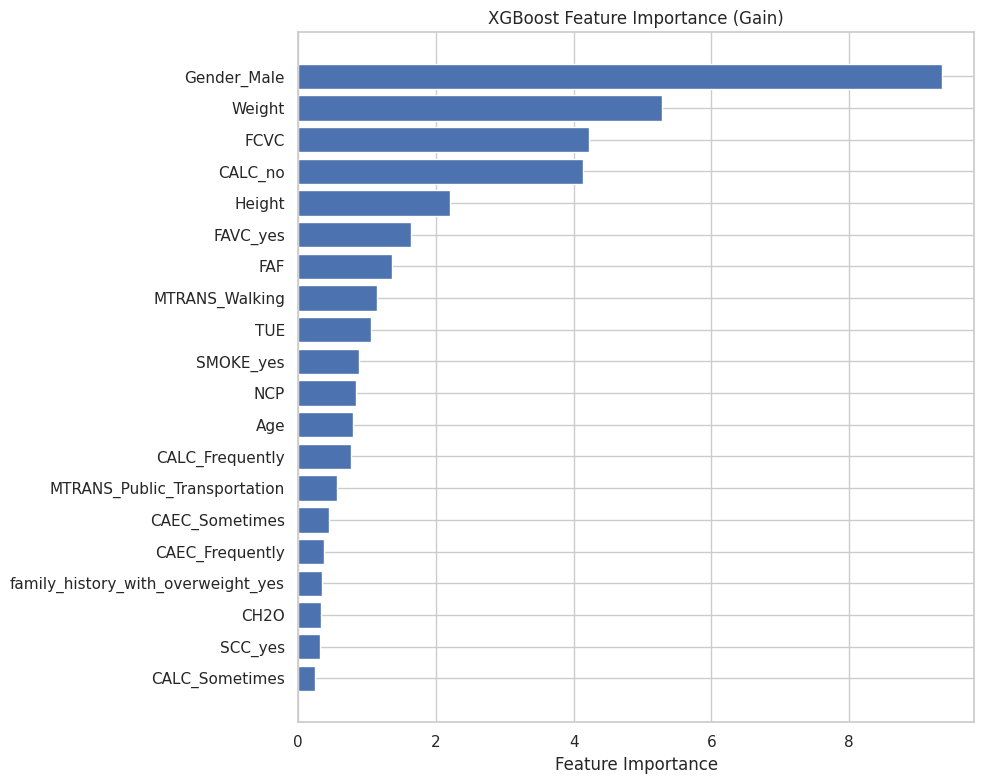

In [40]:
## plot feature importance

# extract importance scores
booster = best_xgb.get_booster()
importance_dict = booster.get_score(importance_type = 'gain')

# convert to dataframe
importance_df = pd.DataFrame({
    'feature_raw': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
})

# extract numeric index from strings like "f0", "f12"
importance_df['feature_index'] = (
    importance_df['feature_raw'].str.extract(r'(\d+)').astype(int)
)

# map index to actual OHE feature name
importance_df['feature'] = importance_df['feature_index'].apply(
    lambda i: xgb_feature_names[i]
)

# sort by importance
importance_df = importance_df.sort_values('importance', ascending = False)

# create plot
plt.figure(figsize = (10, 8))
plt.barh(
    importance_df['feature'],
    importance_df['importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (Gain)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

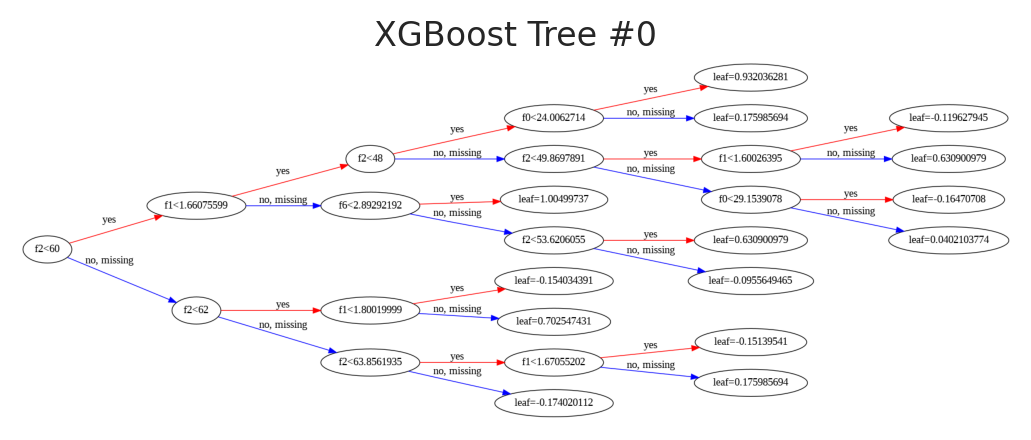

In [41]:
## tree diagram

# get feature names
best_xgb.feature_names = xgb_feature_names

# create plot
plt.rcParams['figure.dpi'] = 200
plot_tree(best_xgb, tree_idx = 0, rankdir = 'LR')
plt.title('XGBoost Tree #0')
plt.show()


## Feature Importance Comparison Plot

Compare feature importance between random forest and XGBoost.

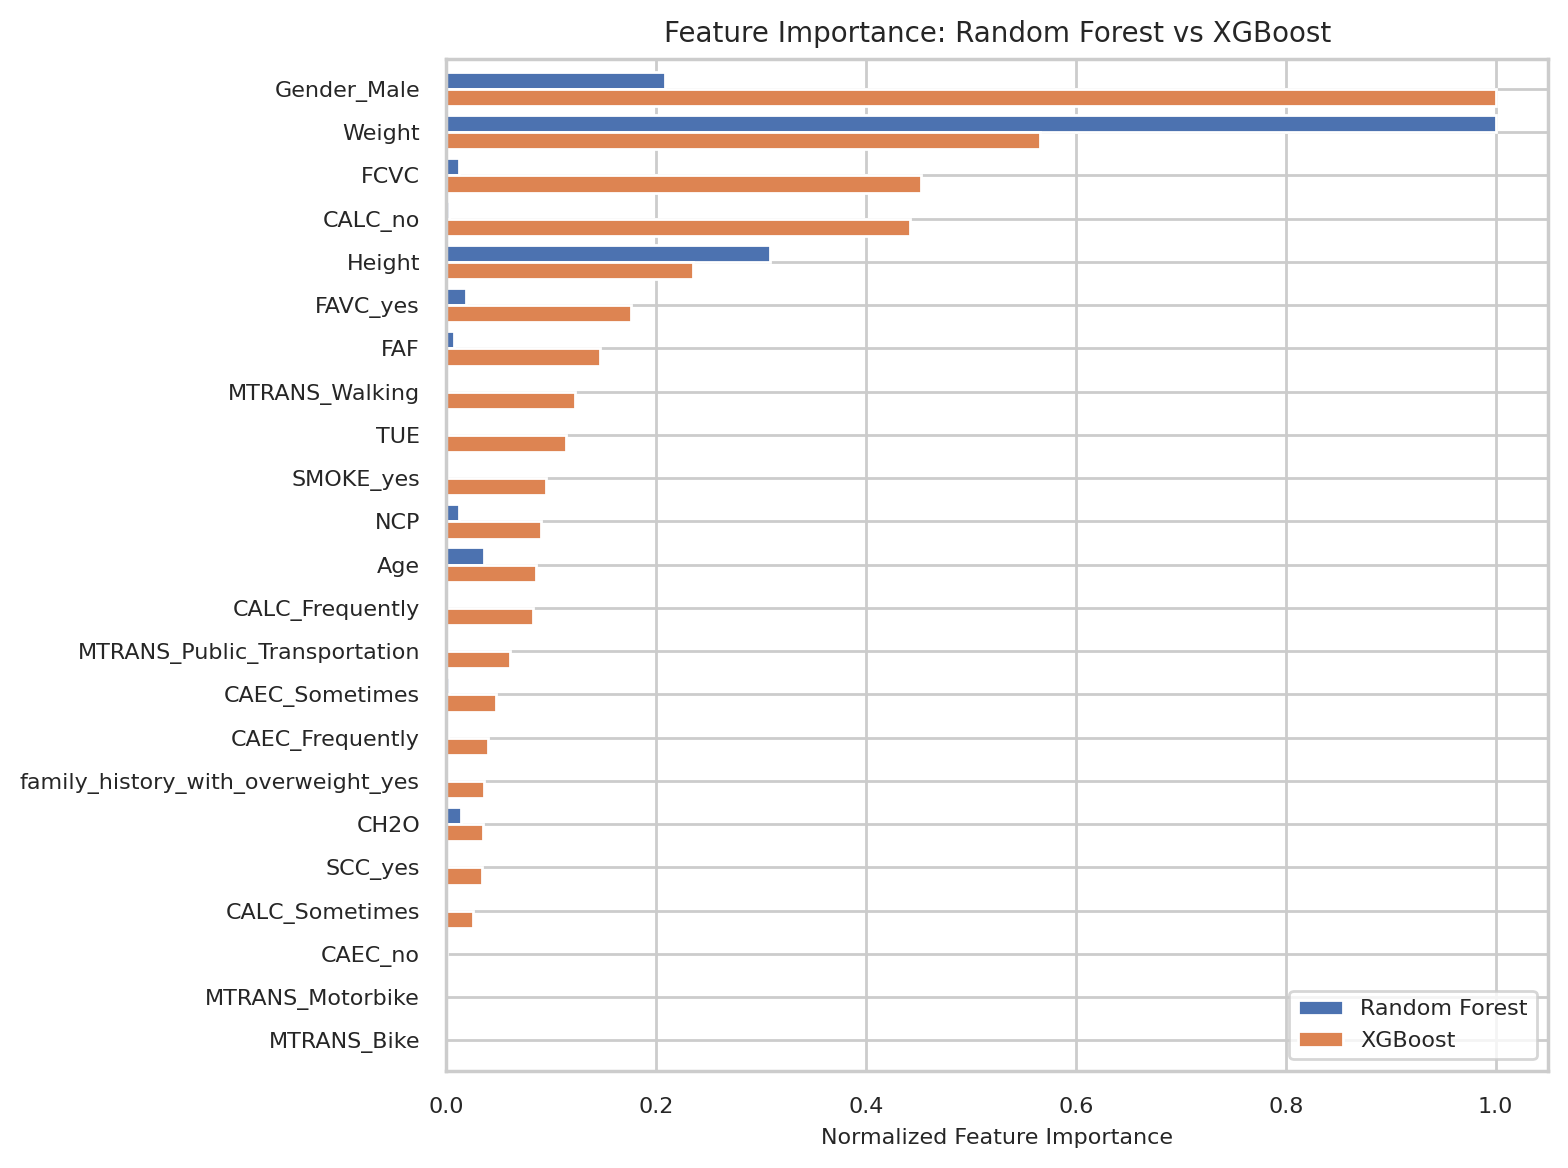

In [42]:
## prep random forest feature importance data
rf_df = pd.DataFrame({
    'feature': rf_feature_names,
    'rf_importance': final_rf.feature_importances_
})

# normalize RF
rf_df['rf_importance'] /= rf_df['rf_importance'].max()

## prep XGBoost feature importance (gain) data
importance_dict = best_xgb.get_booster().get_score(importance_type = 'gain')

xgb_df = pd.DataFrame({
    'feature': [xgb_feature_names[int(k[1:])] for k in importance_dict.keys()],
    'xgb_importance': list(importance_dict.values())
})

# normalize XGBoost
xgb_df['xgb_importance'] /= xgb_df['xgb_importance'].max()

## merge RF and XGBoost
merged = pd.merge(rf_df, xgb_df, on = 'feature', how = 'outer').fillna(0)

# sort by XGBoost importance
merged = merged.sort_values('xgb_importance', ascending = False)

## create combined plot
plt.figure(figsize = (8, 6))
y = range(len(merged))

plt.barh(y, merged['rf_importance'], height = 0.4, label = 'Random Forest')
plt.barh([i + 0.4 for i in y], merged['xgb_importance'], height = 0.4, label = 'XGBoost')

plt.yticks([i + 0.2 for i in y], merged['feature'], fontsize = 8)

plt.ylim(-0.5, len(merged) - 0.1)
plt.xticks(fontsize=8)
plt.xlabel('Normalized Feature Importance', fontsize = 8)
plt.title('Feature Importance: Random Forest vs XGBoost', fontsize = 10)

plt.legend(loc = 'lower right', fontsize = 8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
